# Notebook 3: Random Forest Model (FIXED)
**Project:** ML-Based IDS for IoT Networks | **Student:** Aryan Thapa | AM.SC.P2CSN25005

**Fixes applied:**
- `max_depth=15` prevents overfitting
- `min_samples_leaf=10` stops single-sample leaf memorisation
- `class_weight='balanced'` handles remaining imbalance properly
- Cross-validation added to verify generalisation

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded')

Libraries loaded


## 1. Load Preprocessed Data

In [25]:
X_train       = np.load('../data/processed/X_train.npy')
X_test        = np.load('../data/processed/X_test.npy')
y_train       = np.load('../data/processed/y_train_binary.npy')
y_test        = np.load('../data/processed/y_test_binary.npy')
y_train_multi = np.load('../data/processed/y_train_multi.npy')
y_test_multi  = np.load('../data/processed/y_test_multi.npy')
feature_names = pd.read_csv('../data/processed/feature_names.csv').iloc[:, 0].tolist()
label_encoder = joblib.load('../models/label_encoder.pkl')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'Features: {feature_names}')
print(f'\nTrain class distribution:')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {"Normal" if cls==0 else "Attack"}: {cnt:,} ({cnt/len(y_train)*100:.1f}%)')
print(f'\nTest class distribution:')
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f'  {"Normal" if cls==0 else "Attack"}: {cnt:,} ({cnt/len(y_test)*100:.1f}%)')


X_train: (37370, 10) | X_test: (10807, 10)
y_train: (37370,) | y_test: (10807,)
Features: ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']

Train class distribution:
  Normal: 370 (1.0%)
  Attack: 37,000 (99.0%)

Test class distribution:
  Normal: 107 (1.0%)
  Attack: 10,700 (99.0%)


## 2. Train Binary Random Forest
Key hyperparameters to prevent overfitting:
- `max_depth=15` — trees stop at depth 15, cannot memorise
- `min_samples_leaf=10` — leaf needs 10+ samples, prevents single-sample memorisation
- `n_estimators=200` — more trees = more stable predictions
- `class_weight='balanced'` — compensates for any remaining imbalance

In [26]:
rf_binary = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=4,
    oob_score=True
)
print('Training Binary RF...')
rf_binary.fit(X_train, y_train)
print(f'Done.')
print(f'OOB Score: {rf_binary.oob_score_:.4f}')
print(f'Train Accuracy: {rf_binary.score(X_train, y_train):.4f}')
print(f'Test Accuracy (before CV): {rf_binary.score(X_test, y_test):.4f}')

Training Binary RF...
Done.
OOB Score: 0.9988
Train Accuracy: 0.9990
Test Accuracy (before CV): 0.9986


## 3. Cross-Validation — Verify No Overfitting

In [27]:
# 5-fold stratified CV on training data
# If CV scores are consistent with test scores → no overfitting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-fold cross-validation (this takes a few minutes)...')
cv_scores = cross_val_score(rf_binary, X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)

print(f'\nCV F1 Scores: {cv_scores.round(4)}')
print(f'Mean CV F1:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print()
if cv_scores.std() < 0.02:
    print('Variance is low — model generalises well across folds')
else:
    print('WARNING: High variance across folds — consider tuning further')

Running 5-fold cross-validation (this takes a few minutes)...

CV F1 Scores: [0.9993 0.9995 0.9991 0.9996 0.9997]
Mean CV F1:   0.9994 (+/- 0.0002)

Variance is low — model generalises well across folds


## 4. Evaluate on Test Set

In [28]:
y_pred = rf_binary.predict(X_test)
y_prob = rf_binary.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('BINARY CLASSIFICATION RESULTS')
print('=' * 45)
print(f'Accuracy:  {acc:.4f}  ({acc*100:.2f}%)')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'AUC-ROC:   {auc:.4f}')
print(f'OOB Score: {rf_binary.oob_score_:.4f}')
print(f'CV F1 Mean:{cv_scores.mean():.4f}')
print()
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Attack'], zero_division=0))

BINARY CLASSIFICATION RESULTS
Accuracy:  0.9986  (99.86%)
Precision: 0.9999
Recall:    0.9987
F1-Score:  0.9993
AUC-ROC:   1.0000
OOB Score: 0.9988
CV F1 Mean:0.9994

              precision    recall  f1-score   support

      Normal       0.88      0.99      0.93       107
      Attack       1.00      1.00      1.00     10700

    accuracy                           1.00     10807
   macro avg       0.94      0.99      0.97     10807
weighted avg       1.00      1.00      1.00     10807



## 5. Confusion Matrix

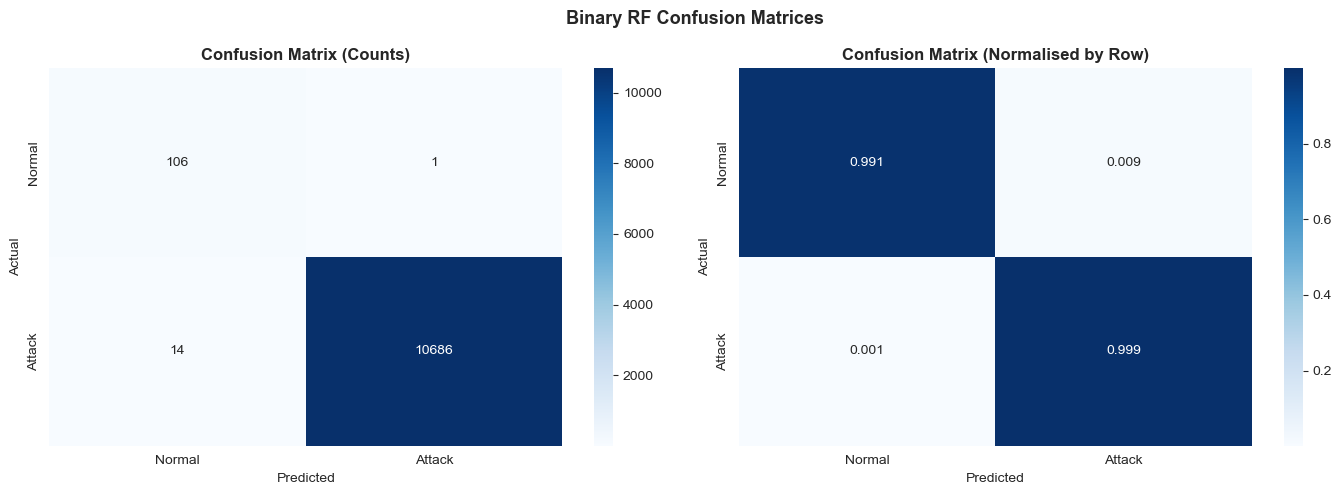

True Negatives  (correct normal):  106
False Positives (false alarms):    1
False Negatives (missed attacks):  14
True Positives  (caught attacks):  10,686
False Positive Rate: 0.0093
False Negative Rate: 0.0013


In [29]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalised per row
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised by Row)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('Binary RF Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/rf_binary_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct normal):  {tn:,}')
print(f'False Positives (false alarms):    {fp:,}')
print(f'False Negatives (missed attacks):  {fn:,}')
print(f'True Positives  (caught attacks):  {tp:,}')
print(f'False Positive Rate: {fp/(fp+tn):.4f}')
print(f'False Negative Rate: {fn/(fn+tp):.4f}')

## 6. ROC Curve

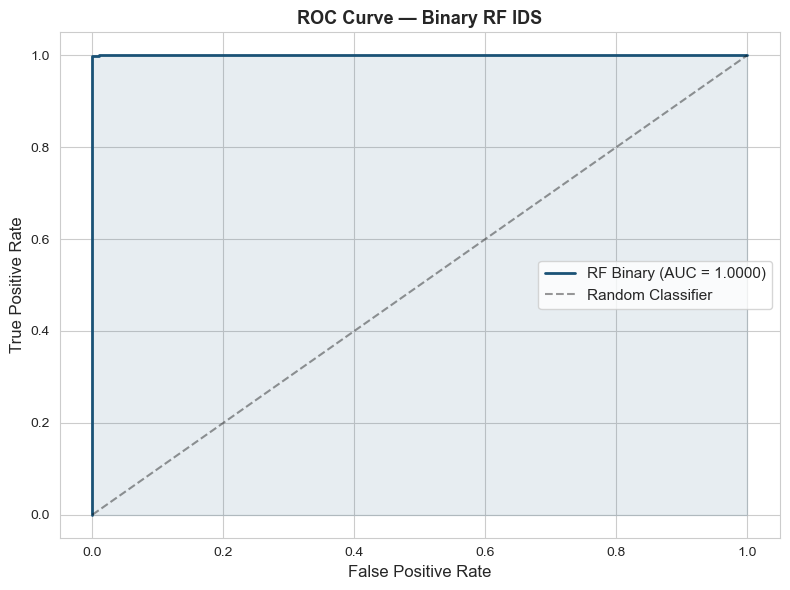

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1A5276', lw=2,
         label=f'RF Binary (AUC = {auc:.4f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#1A5276')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Binary RF IDS', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../reports/rf_binary_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Train Multi-Class RF

In [31]:
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=4
)
print('Training Multi-Class RF...')
rf_multi.fit(X_train, y_train_multi)
print('Done.')

y_pred_multi = rf_multi.predict(X_test)
class_names  = label_encoder.classes_
mc_acc = accuracy_score(y_test_multi, y_pred_multi)

print(f'\n=== MULTI-CLASS RESULTS ===')
print(f'Accuracy: {mc_acc:.4f}')
print()
print(classification_report(y_test_multi, y_pred_multi,
      target_names=class_names, zero_division=0))


Training Multi-Class RF...
Done.

=== MULTI-CLASS RESULTS ===
Accuracy: 0.9870

                precision    recall  f1-score   support

          DDoS       0.99      0.99      0.99      5662
           DoS       0.99      0.99      0.99      4772
        Normal       0.90      1.00      0.95       107
Reconnaissance       1.00      0.97      0.98       265
         Theft       0.00      0.00      0.00         1

      accuracy                           0.99     10807
     macro avg       0.77      0.79      0.78     10807
  weighted avg       0.99      0.99      0.99     10807



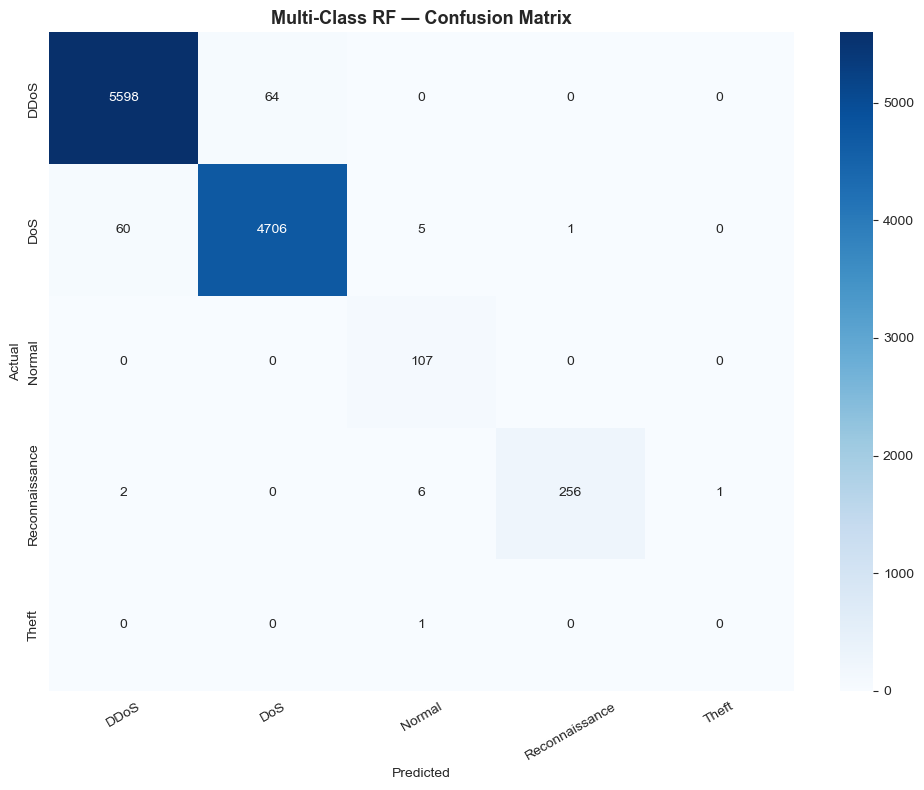

In [32]:
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multi-Class RF — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/rf_multiclass_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

=== FEATURE IMPORTANCES ===
          feature  importance
N_IN_Conn_P_DstIP    0.435574
              seq    0.218205
N_IN_Conn_P_SrcIP    0.166004
           stddev    0.081254
            srate    0.043974
              max    0.025433
             mean    0.014844
     state_number    0.011008
              min    0.002620
            drate    0.001084


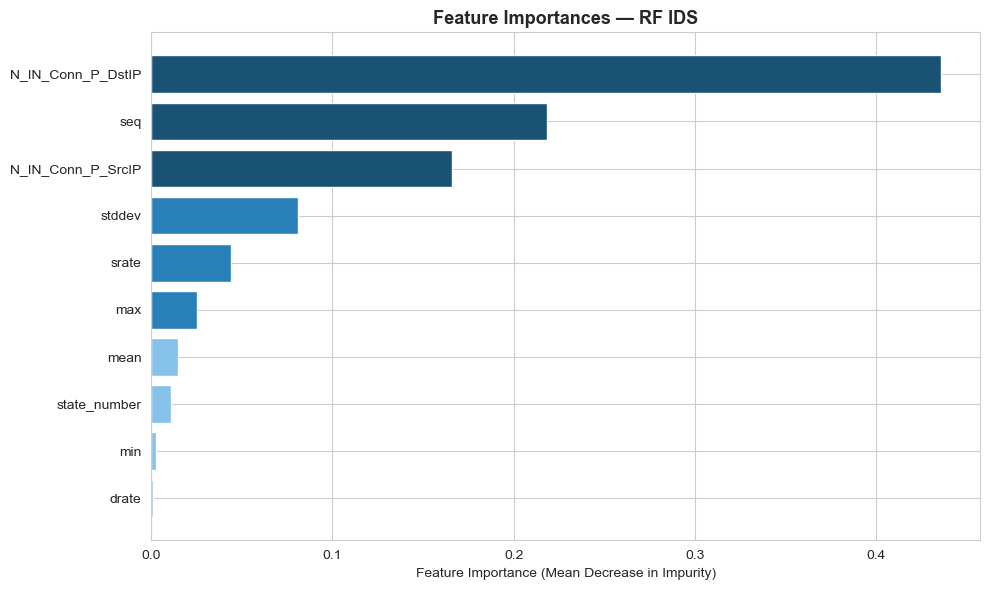

In [33]:
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_binary.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('=== FEATURE IMPORTANCES ===')
print(feat_imp.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['#1A5276' if i < 3 else '#2980B9' if i < 6 else '#85C1E9'
          for i in range(len(feat_imp))]
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color=colors[::-1])
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title('Feature Importances — RF IDS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
feat_imp.to_csv('../data/processed/rf_feature_importances.csv', index=False)

## 9. Save Models

In [34]:
joblib.dump(rf_binary, '../models/random_forest_binary.pkl')
joblib.dump(rf_multi,  '../models/random_forest_multiclass.pkl')
print('Saved: random_forest_binary.pkl')
print('Saved: random_forest_multiclass.pkl')
print()
print('=' * 45)
print('RF SUMMARY')
print('=' * 45)
print(f'Binary  Accuracy:  {acc:.4f}')
print(f'Binary  F1-Score:  {f1:.4f}')
print(f'Binary  AUC-ROC:   {auc:.4f}')
print(f'Binary  OOB Score: {rf_binary.oob_score_:.4f}')
print(f'CV F1 Mean:        {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Multi   Accuracy:  {mc_acc:.4f}')
print(f'Top feature: {feat_imp.iloc[0]["feature"]}')
print('\nNext -> 04_IsolationForest.ipynb')

Saved: random_forest_binary.pkl
Saved: random_forest_multiclass.pkl

RF SUMMARY
Binary  Accuracy:  0.9986
Binary  F1-Score:  0.9993
Binary  AUC-ROC:   1.0000
Binary  OOB Score: 0.9988
CV F1 Mean:        0.9994 +/- 0.0002
Multi   Accuracy:  0.9870
Top feature: N_IN_Conn_P_DstIP

Next -> 04_IsolationForest.ipynb
